# Lab 1 - Observabilidad: ETL + outliers + alertas

**Modalidad:** guiado - **Duracion:** ~12 min
**Datasets:** metrics_timeseries.csv, incidents.csv, slo_burn.csv

## El caso de negocio

Somos SREs de una plataforma de pagos. El director nos pregunta:

> «Nuestros proveedores cloud nos ofrecen reservar capacidad por 1 año con 30% de descuento. ¿Cual servicio necesita mas capacidad ya, y cual podria moverse a otro mas barato?»

Para responder necesitamos ver: (1) cual servicio consume **mas CPU** consistentemente, (2) cual tiene **picos recurrentes** en horarios especificos, (3) cual esta **saturado** permanentemente.

## Entregable
5 figuras + 1 tabla con recomendacion de capacidad por servicio.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('..') / 'data'
metrics = pd.read_csv(DATA / 'metrics_timeseries.csv', parse_dates=['ts'])
incidents = pd.read_csv(DATA / 'incidents.csv', parse_dates=['opened_at', 'resolved_at'])
burn = pd.read_csv(DATA / 'slo_burn.csv', parse_dates=['ts'])
print(f'Metricas: {len(metrics):,} filas, {metrics["service"].nunique()} servicios')
print(f'Incidentes: {len(incidents)}')
print('Servicios:', metrics['service'].unique())

Metricas: 972,015 filas, 5 servicios
Incidentes: 35
Servicios: <StringArray>
['checkout-api', 'auth-service', 'search-api', 'billing-worker',
 'notifications']
Length: 5, dtype: str


## 1. Diagnostico de la calidad de los datos

**Que buscamos:** ¿hay NaN o valores fisicamente imposibles que distorsionen nuestras conclusiones?

**Por que importa:** si hay `latency_ms = -50` en el dataset, cualquier grafico de distribucion arrastra la media hacia abajo. El director recibe un numero falso y compra capacidad que no necesita.

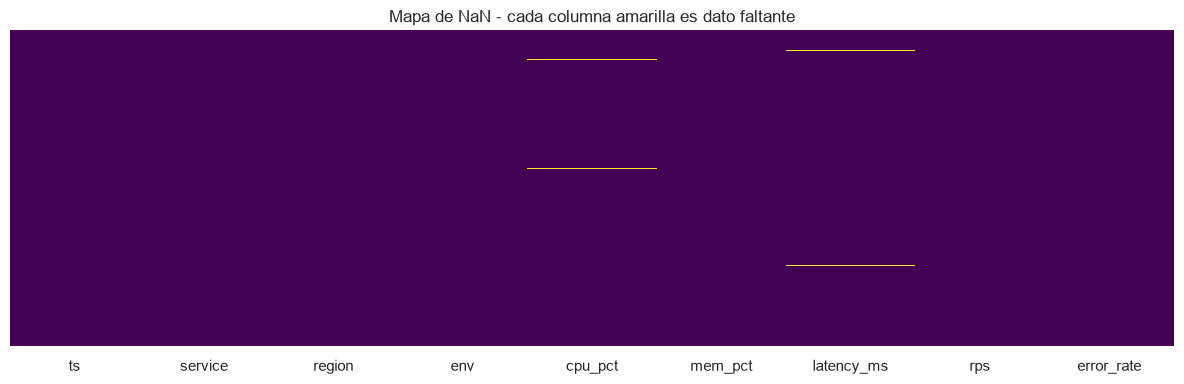

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(metrics.isnull(), cbar=False, yticklabels=False, cmap='viridis')
ax.set_title('Mapa de NaN - cada columna amarilla es dato faltante')
plt.tight_layout()
plt.savefig('../html/lab1_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

## 2. Limpieza: que hacemos con NaN y errores

**Reglas que aplicamos** (explicitas para nuevos SREs):
- **`latency_ms < 0`**: error del exporter (reloj desincronizado) → **borrar**
- **`latency_ms > 10 000`** (10s): bug o exporter colgado → **borrar**
- **`cpu_pct > 100`**: imposible, CPU > 100% → **borrar**
- **NaN en numericas**: imputar con la **mediana** del servicio (es robusta a outliers).

In [3]:
def clean_numeric(df, col, lo, hi):
    bad = (df[col] < lo) | (df[col] > hi)
    print(f'{col}: {bad.sum()} valores imposibles')
    df = df.loc[~bad].copy()
    df[col] = df[col].fillna(df[col].median())
    return df

metrics_clean = clean_numeric(metrics, 'latency_ms', 0, 10_000)
metrics_clean = clean_numeric(metrics_clean, 'cpu_pct', 0, 100)
print(f'\nShape limpio: {metrics_clean.shape}')

latency_ms: 3869 valores imposibles


cpu_pct: 63511 valores imposibles



Shape limpio: (904635, 9)


## 3. Personalidad de cada servicio - ¿consumen distinto?

**Que miramos:** agregamos CPU, latencia, memoria y error_rate por servicio con dos metricas clave:
- **Media**: lo que consume **en promedio**
- **p95**: lo que consume en el **peor 5% de los minutos**

**Por que importa p95?** Porque las nubes cobran por picos, no por promedio. Si tu promedio es 30% pero tu p95 es 85%, necesitas capacidad para 85%, no para 30%.

**Que es 'headroom'?** Es la **distancia hasta el 100%**. Si headroom = 15%, significa que el 5% del tiempo tu servicio esta al 85% de CPU (100% - 15%). Si headroom = 30%, tienes margen para crecer.

In [4]:
agg = metrics_clean.groupby('service').agg(
    cpu_mean=('cpu_pct', 'mean'),
    cpu_p95=('cpu_pct', lambda s: s.quantile(0.95)),
    mem_mean=('mem_pct', 'mean'),
    lat_p95=('latency_ms', lambda s: s.quantile(0.95)),
    err_mean=('error_rate', 'mean'),
).round(2)
agg['cpu_headroom'] = (100 - agg['cpu_p95']).round(1)
agg

,cpu_mean,cpu_p95,mem_mean,lat_p95,err_mean,cpu_headroom
service,,,,,,
auth-service,27.35,41.43,46.17,129.3,0.0,58.6
billing-worker,30.23,52.79,46.22,948.8,0.0,47.2
checkout-api,40.47,64.43,57.25,174.9,0.0,35.6
notifications,14.55,24.91,36.95,93.0,0.0,75.1
search-api,46.68,64.45,64.63,400.4,0.0,35.6


## 4. Decision visual - ¿quien necesita capacidad ya?

**Reglas para leer este grafico**:
- Barra **roja** (CPU p95): si supera 80%, el servicio **roza la saturacion**
- Linea naranja: umbral critico (80%)
- Si la barra de **latencia** (gris) esta alta junto con CPU alto = **señal de saturacion real** (los requests se quedan esperando CPU)
- Si CPU es alto pero latencia es baja = probablemente **puede escalar** sin urgencia

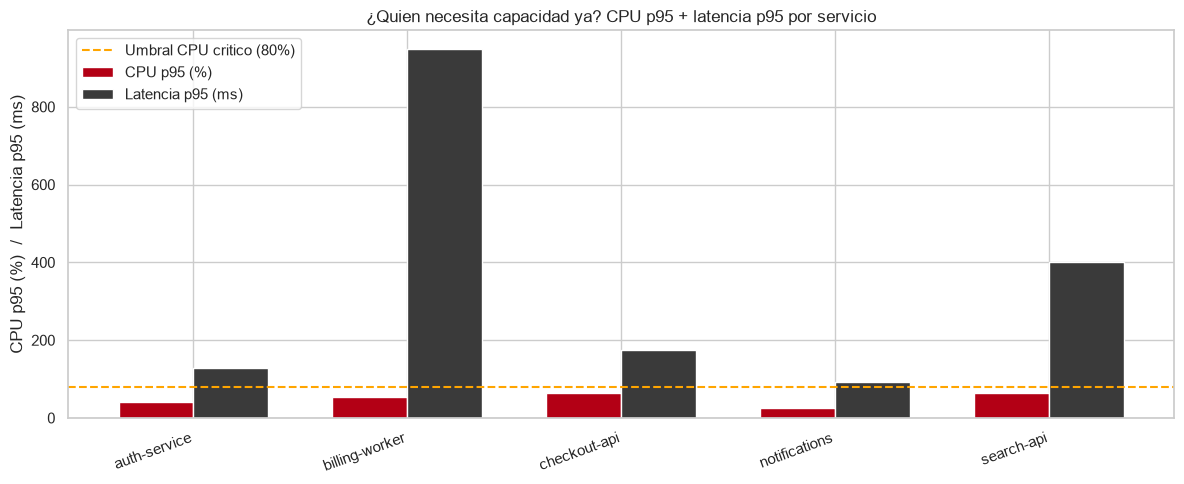

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
services = agg.index.tolist()
x = np.arange(len(services))
width = 0.35
ax.bar(x - width/2, agg['cpu_p95'], width, label='CPU p95 (%)', color='#b30015')
ax.bar(x + width/2, agg['lat_p95'], width, label='Latencia p95 (ms)', color='#3a3a3a')
ax.axhline(y=80, color='orange', linestyle='--', label='Umbral CPU critico (80%)')
ax.set_xticks(x)
ax.set_xticklabels(services, rotation=20, ha='right')
ax.set_ylabel('CPU p95 (%)  /  Latencia p95 (ms)')
ax.set_title('¿Quien necesita capacidad ya? CPU p95 + latencia p95 por servicio')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../html/lab1_fig2_capacity.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Heatmap dia x hora x servicio - ¿cuando hay alertas?

**Que vemos:** el percentil 95 de CPU por servicio, por dia de la semana (eje Y) y hora del dia (eje X). Las celdas mas oscuras = mas CPU en el peor caso.

**Para que sirve:**
- Si un servicio tiene **picos claros lunes 9-11am** = oportunidad de auto-scaling programado (configura 2x capacidad solo en esa franja).
- Si los picos son **uniformes** = necesitas capacidad constante (compra ya).
- Si los fines de semana son **bajos** = oportunidad de apagarlo (ahorra dinero).

**Por que p95 y no media:** la media esconde los picos. El p95 te dice el peor caso realista del 5% de los minutos.

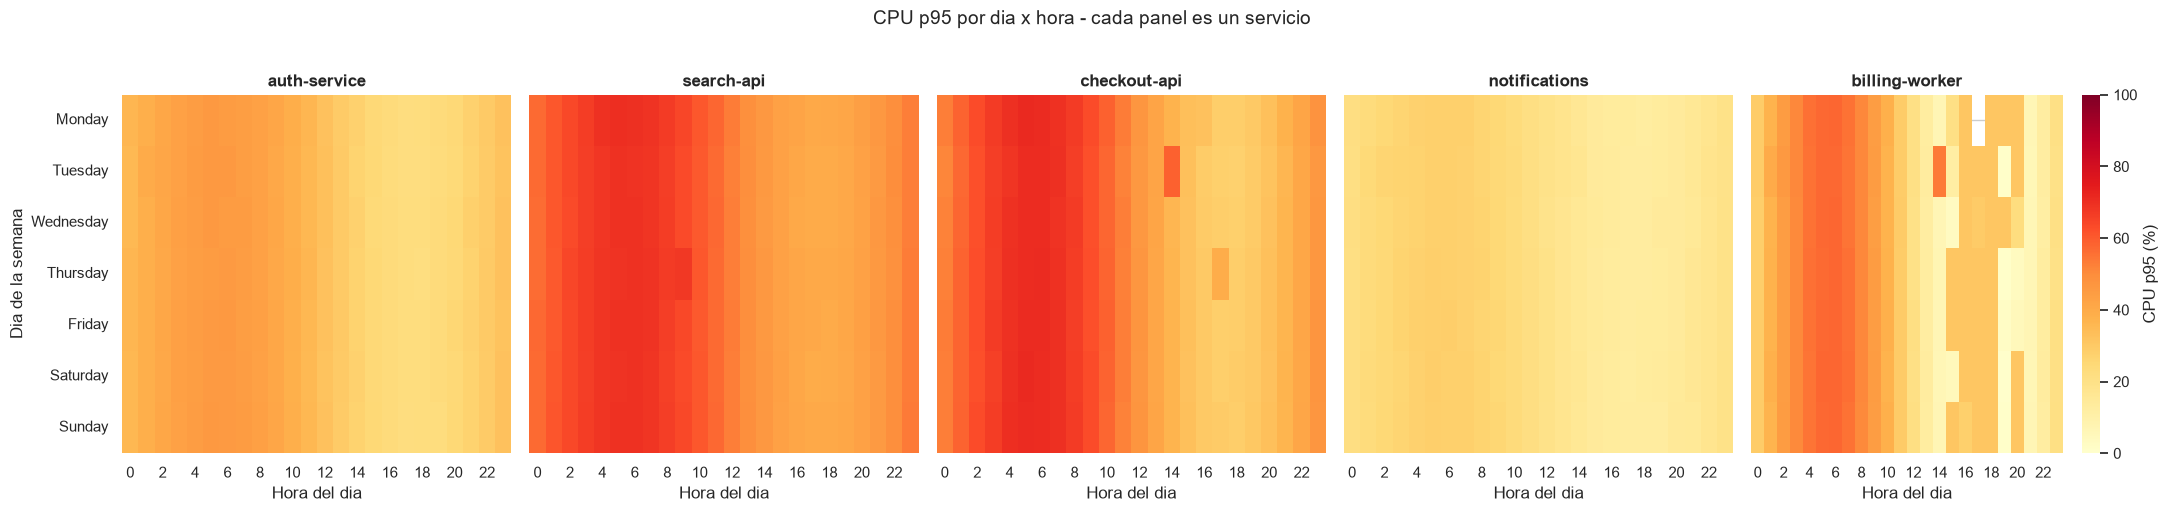

In [6]:
metrics_clean['dow'] = metrics_clean['ts'].dt.day_name()
metrics_clean['hour'] = metrics_clean['ts'].dt.hour
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
metrics_clean['dow'] = pd.Categorical(metrics_clean['dow'], categories=dow_order, ordered=True)

# Heatmap en grilla 1 fila x 5 columnas (uno por servicio)
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True, sharex=True)
services_sorted = metrics_clean['service'].value_counts().index.tolist()
for ax, svc in zip(axes, services_sorted):
    sub = metrics_clean[metrics_clean['service'] == svc]
    pivot = sub.pivot_table(index='dow', columns='hour', values='cpu_pct', aggfunc=lambda s: s.quantile(0.95))
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', vmin=0, vmax=100,
                cbar=(svc == services_sorted[-1]),
                cbar_kws={'label': 'CPU p95 (%)'} if svc == services_sorted[-1] else None)
    ax.set_title(svc, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hora del dia')
    ax.set_ylabel('Dia de la semana' if svc == services_sorted[0] else '')
fig.suptitle('CPU p95 por dia x hora - cada panel es un servicio', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../html/lab1_fig3_heatmap_alerts.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Boxplot por servicio - los outliers reales

**Que es un boxplot?** Resume una distribucion en 5 numeros clave:
- **Caja (Q1-Q3)**: el 50% tipico de tus runs
- **Rayita central**: la mediana
- **Bigotes**: rango normal (1.5x IQR)
- **Puntos arriba**: outliers = runs anormales

**Por que escala log en este caso?** La latencia varia de 60 ms (notifications) a 600+ ms (search-api). En escala lineal, los pequeños se aplastan contra cero y no ves nada. La escala log te deja comparar extremos.

**Que decision tomamos?** Si los outliers arriba del bigote son picos recurrentes = incidente real (investigar). Si estan en ambos lados = bug.

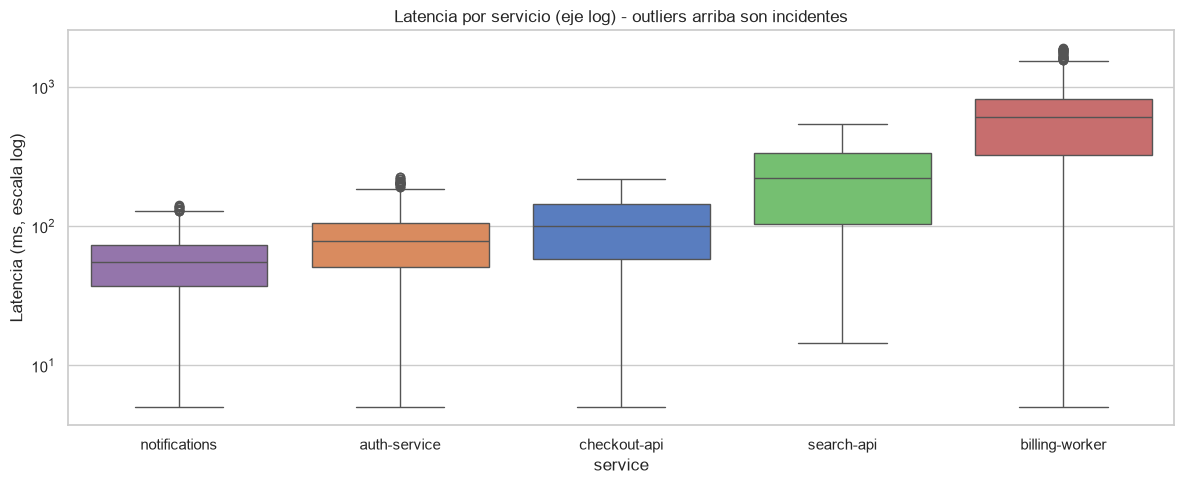

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
order = metrics_clean.groupby('service')['latency_ms'].median().sort_values().index
sns.boxplot(data=metrics_clean, x='service', y='latency_ms', order=order, hue='service', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Latencia por servicio (eje log) - outliers arriba son incidentes')
ax.set_ylabel('Latencia (ms, escala log)')
plt.tight_layout()
plt.savefig('../html/lab1_fig4_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Tu decision como SRE

Mirando los datos de la tabla de la seccion 3:

1. **Compra de capacidad**: el servicio con **headroom < 15%** y **lat_p95 alta** esta saturado - compra 2 nodos ahora (30% descuento reserva anual).
2. **Auto-scaling**: el servicio con **picos claros en horas especificas** (mira el heatmap de la seccion 5) - configura regla auto-scaling.
3. **Bajar tier**: el servicio con **headroom > 40%** y **lat_p95 baja** - muevelo al plan basico del proveedor cloud.

**Argumenta con datos, no con intuicion.** Muestra tu tabla y tu heatmap al facilitador.

## 8. Para presentar al director

Tu headline ejecutiva (1 linea):

> «El servicio **[NOMBRE]** tiene CPU p95 del **X%** con headroom del **Y%**; compramos 2 nodos con 30% de descuento = **$Z** ahorrados al año.»

Usa los numeros de la tabla de la seccion 3.